# EDA de detección de anomalías por ventanas en hornos industriales para cereales

## Contexto de los datos

El notebook analiza registros temporales de ciclos completos de horno. Cada fila representa un instante de operación, contiene las mediciones de los sensores configurados y usa `fault_name` para indicar si ese instante es normal (`NORMAL`) o pertenece a un tramo con fallo.

## Fuentes de datos

Hay dos formas de alimentar este EDA:

1. **Splits ya creados** (`data/splits/train.csv`, `val.csv`, `test.csv`): ruta rápida cuando se dispone de splits generados previamente (por ejemplo ejecutando `scripts/generate_dataset.py` o tras dividir un dataset externo con `scripts/split_external_data.py`).
2. **Dataset raw**: útil cuando se parte de un dataset completo sin splits (por ejemplo, un CSV proporcionado por un cliente). En este caso, basta especificar la ruta al archivo y el notebook aplicará `split_external_data()` para generar los splits en memoria.

La variable `DATA_SOURCE` en la celda de configuración permite elegir la fuente. Si se elige `splits` y los archivos no existen, se lanzará un error. Si se elige `raw`, hay que rellenar también `RAW_DATA_PATH` con la ruta al archivo.

> **Nota:** Cuando se usa un dataset raw, el split se calcula con los porcentajes definidos en `config/config.yaml` bajo `data_processing.external_data_split` (por defecto: train=66.7%, val=13.3%, test=20.0%). El split se realiza por ID (`cycle_id`) cuando está disponible, o por orden temporal como fallback.

## Unidad de análisis

El ciclo se usa como contexto temporal, pero no como etiqueta supervisada. Un ciclo puede empezar normal, contener un tramo con fallo y terminar de nuevo en estado normal. Por ello, la unidad relevante para el modelo es la **ventana temporal** creada por `create_sequences()` con los parámetros de `config/config.yaml` (`sequence_length`, `solapamiento_beta`, `id_column` y `normal_tokens`).

Una ventana se etiqueta como anomalía cuando al menos el 50 % de sus registros son anómalos. Este criterio replica la lógica de `_window_target_label` y evita asumir que todo el ciclo tiene el mismo estado.

## Objetivos del EDA

- Comprobar origen, volumen, cobertura temporal, ciclos disponibles y completitud de sensores.
- Revisar el balance normal/anomalía a nivel de registro y la distribución de tipos de fallo (`fault_base`).
- Usar los ciclos como contexto para medir cuánta parte de cada ciclo está afectada por fallo y qué fallo domina.
- Construir ventanas con la misma lógica del pipeline y validar que la etiqueta reconstruida coincide con `create_sequences()`.
- Analizar el balance de ventanas normales/anómalas y el efecto del umbral del 50 % de registros anómalos.
- Identificar fallos dominantes por ventana, perfiles temporales de sensores y estadísticos de ventana con mayor separabilidad.
- Visualizar la separación mediante distribuciones, PCA y correlaciones entre características estadísticas.

In [1]:
import warnings
from pathlib import Path
import sys

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "config.yaml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("No se pudo localizar la raiz del repositorio desde el directorio actual.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data_processing.preprocess import create_sequences, stats_windows, _anomaly_mask, split_train_val_test_by_id

CONFIG_PATH = REPO_ROOT / "config" / "config.yaml"
with CONFIG_PATH.open("r", encoding="utf-8") as fh:
    config = yaml.safe_load(fh)

data_cfg = config["data_processing"]
gen_cfg = config["data_generation"]
paths_cfg = config["paths"]

target_column = str(data_cfg.get("target_column", "fault_name")).lower()
id_column = str(data_cfg.get("id_column", "cycle_id")).lower() if data_cfg.get("id_column") else None
timestamp_column = str(data_cfg.get("timestamp_column", "timestamp")).lower()
normal_tokens = data_cfg.get("normal_tokens", ["NORMAL"])
seq_length = int(data_cfg.get("sequence_length", 180))
solapamiento_beta = float(data_cfg.get("solapamiento_beta", 0.5))
window_step = max(1, int(seq_length * (1 - solapamiento_beta)))
stats_creation = data_cfg.get("fuzzy_processing", {}).get("stats_creation", ["mean", "std"])

sensor_cols = [str(sensor["name"]).lower() for sensor in gen_cfg.get("sensors", [])]
fault_type_names = [str(item["name"]).upper() for item in gen_cfg.get("fault_types", [])]
fault_base_names = sorted([name for name in fault_type_names if name != "NORMAL"], key=len, reverse=True)

print(f"Target: {target_column} | ID: {id_column} | Timestamp: {timestamp_column}")
print(f"Ventana: sequence_length={seq_length}, solapamiento_beta={solapamiento_beta}, step={window_step}")
print(f"Sensores esperados ({len(sensor_cols)}): {sensor_cols}")

Target: fault_name | ID: cycle_id | Timestamp: timestamp
Ventana: sequence_length=180, solapamiento_beta=0.5, step=90
Sensores esperados (13): ['temp_zona1', 'temp_zona2', 'temp_zona3', 'temp_salida_gases', 'presion_camara', 'presion_ventilacion', 'potencia_kw', 'flujo_gas', 'humedad_relativa', 'temp_ambiente', 'setpoint_temp', 'posicion_valvula', 'velocidad_ventilador']


## Configuración de fuente de datos

Elige `splits` para usar los archivos ya existentes en `data/splits/`, o `raw` para cargar un dataset completo y generar los splits en el momento.

> **Nota:** Cuando se usa `raw`, los porcentajes de split se leen desde `config/config.yaml` → `data_processing.external_data_split` (por defecto: train=66.7 %, val=13.3 %, test=20.0 %). El split se realiza por ID cuando `cycle_id` está disponible.


In [2]:
# Fuente de datos: "splits" o "raw"
DATA_SOURCE = "splits"  # Cambiar a "raw" si se parte de un dataset sin splits

# Ruta al archivo raw (solo necesario si DATA_SOURCE == "raw")
RAW_DATA_PATH = "data/raw/oven_full_dataset.csv"  
# IMPORTANTE usar forward slashes (/) como separador para evitar que interprete \r como carriage return

## 1) Carga y calidad básica de los datos

Este apartado identifica qué fuente se ha cargado, cuántos registros contiene, qué rango temporal cubre y cuántos ciclos o IDs distintos aparecen. La primera tabla resume el número de registros por split (`train`, `val`, `test`), lo que permite verificar si la partición tiene el tamaño esperado.

La segunda tabla muestra la proporción de valores nulos por sensor. Valores cercanos a 0 indican que las variables están completas; proporciones elevadas señalan que podría ser necesaria imputación, filtrado o revisión del origen de datos antes de entrenar o interpretar resultados.

In [3]:
def read_frame(path: Path, split_name: str) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame.columns = frame.columns.str.strip().str.lower()
    frame["split"] = split_name
    return frame


def process_frames():
    """Procesa todos los frames: convierte tipos, valida columnas y ordena."""
    for split_name, frame in frames.items():
        missing = [col for col in required_cols if col not in frame.columns]
        if missing:
            raise ValueError(f"{split_name}: faltan columnas requeridas: {missing}")
        frame[timestamp_column] = pd.to_datetime(frame[timestamp_column], errors="coerce")
        if frame[timestamp_column].isna().any():
            bad = int(frame[timestamp_column].isna().sum())
            raise ValueError(f"{split_name}: {bad} timestamps no se pudieron convertir a datetime.")
        for col in sensor_cols:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
        sort_cols = [timestamp_column]
        if id_column and id_column in frame.columns:
            sort_cols = [id_column, timestamp_column]
        frames[split_name] = frame.sort_values(sort_cols).reset_index(drop=True)


required_cols = [timestamp_column, target_column, *sensor_cols]
if id_column:
    required_cols.insert(1, id_column)

if DATA_SOURCE == "splits":
    split_paths = {
        "train": REPO_ROOT / "data" / "splits" / "train.csv",
        "val": REPO_ROOT / "data" / "splits" / "val.csv",
        "test": REPO_ROOT / "data" / "splits" / "test.csv",
    }
    if not all(path.exists() for path in split_paths.values()):
        missing = [name for name, path in split_paths.items() if not path.exists()]
        raise FileNotFoundError(
            f"Splits no encontrados: {missing}. Genera los datos primero ejecutando "
            "scripts/generate_dataset.py, o cambia DATA_SOURCE a 'raw'."
        )
    frames = {split: read_frame(path, split) for split, path in split_paths.items()}
    dataset_source = "splits"
    process_frames()

elif DATA_SOURCE == "raw":
    raw_path = REPO_ROOT / RAW_DATA_PATH
    if not raw_path.exists():
        raise FileNotFoundError(f"Archivo raw no encontrado: {raw_path}")
    raw_df = pd.read_csv(raw_path)
    raw_df.columns = raw_df.columns.str.strip().str.lower()
    split_cfg = data_cfg.get("external_data_split", {})
    train_pct = float(split_cfg.get("train_pct", 66.7))
    val_pct = float(split_cfg.get("val_pct", 13.3))
    test_pct = float(split_cfg.get("test_pct", 20.0))
    val_size = val_pct / 100.0
    test_size = test_pct / 100.0
    print(f"Split desde raw: train={train_pct} %, val={val_pct} %, test={test_pct} %")
    split_data, _ = split_train_val_test_by_id(
        raw_df,
        id_col=id_column if id_column else "cycle_id",
        target_column=target_column,
        val_size=val_size,
        test_size=test_size,
        normal_tokens=normal_tokens,
    )
    frames = {}
    for split_name in ["train", "val", "test"]:
        frame = split_data[split_name].copy()
        frame["split"] = split_name
        frames[split_name] = frame
    dataset_source = f"raw → {RAW_DATA_PATH} (split: {train_pct}/{val_pct}/{test_pct}%)"
    process_frames()
else:
    raise ValueError(f"DATA_SOURCE debe ser 'splits' o 'raw', no '{DATA_SOURCE}'")

df = pd.concat(frames.values(), ignore_index=True)

print(f"Fuente de datos: {dataset_source}")
print(f"Registros totales: {len(df):,}")
print(f"Rango temporal: {df[timestamp_column].min()} -> {df[timestamp_column].max()}")
if id_column and id_column in df.columns:
    print(f"Ciclos/IDs: {df[id_column].nunique():,}")
print("Registros por split:")
display(df["split"].value_counts().rename_axis("split").to_frame("Registros"))

sensor_nulls = df[sensor_cols].isna().mean().sort_values(ascending=False).to_frame("Proporción de NaN/null")
display(sensor_nulls.head(13))

Fuente de datos: splits
Registros totales: 1,800,000
Rango temporal: 2026-01-01 00:00:00 -> 2030-02-08 21:59:00
Ciclos/IDs: 3,000
Registros por split:


,Registros
split,
train,1200000
test,360000
val,240000


,Proporción de NaN/null
temp_zona1,0.0
temp_zona2,0.0
temp_zona3,0.0
temp_salida_gases,0.0
presion_camara,0.0
presion_ventilacion,0.0
potencia_kw,0.0
flujo_gas,0.0
humedad_relativa,0.0
temp_ambiente,0.0


## 2) Etiquetado temporal y distribución de tipos de fallo

Aquí `fault_name` se transforma en dos variables auxiliares: `point_is_anomaly`, que separa registros normales y anómalos, y `fault_base`, que agrupa variantes de una misma familia de fallo. Por ejemplo, distintos casos de `SENSOR_DESCALIBRADO_*` se leen como `SENSOR_DESCALIBRADO`.

La primera tabla presenta el balance global de registros normales y anómalos. La segunda tabla desglosa solo los registros anómalos por tipo de fallo base, mostrando qué fallos tienen más presencia en el dataset.

La primera gráfica compara registros normales y anómalos por split. Si un split concentra muchas más anomalías que otro, la evaluación puede quedar sesgada. La segunda gráfica muestra la distribución de registros anómalos por tipo de fallo y split; sirve para detectar fallos poco representados o desequilibrios entre entrenamiento, validación y test.

,Registros,Porcentaje
point_state,,
Normal,1621503,90.08
Anomalia,178497,9.92


,registros_anomalos,Porcentaje_anomalo
fault_base,,
SENSOR_DESCALIBRADO,34746,19.47
AISLAMIENTO_DEGRADADO,31388,17.58
VALVULA_OBSTRUIDA,29417,16.48
REFRACTARIO_EROSIONADO,28452,15.94
RESISTENCIA_DEGRADADA,28312,15.86
VENTILADOR_DEFECTUOSO,26182,14.67


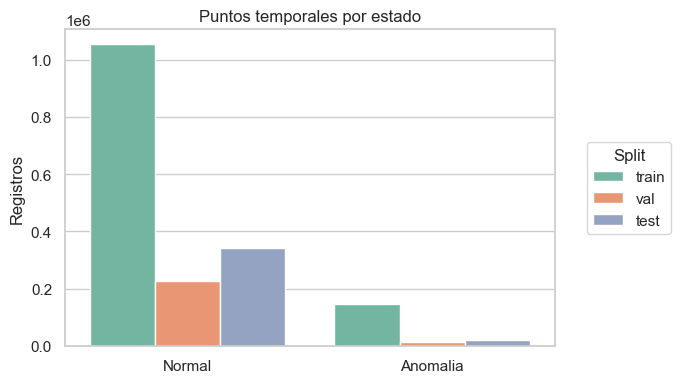

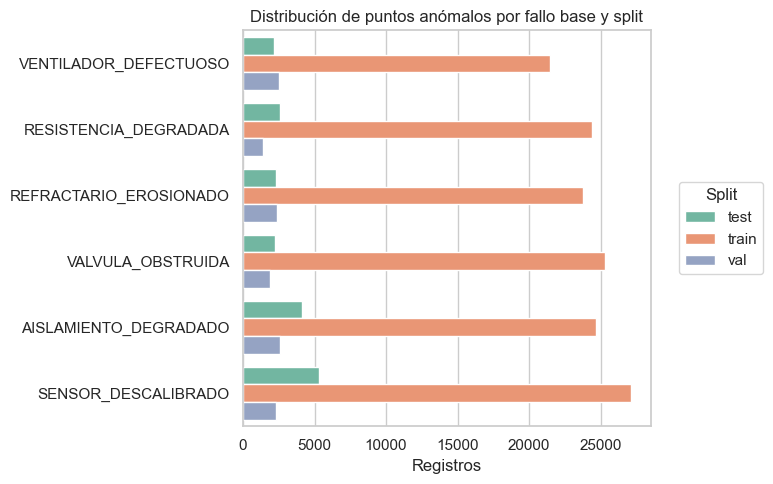

In [4]:
normal_token_set = {str(token).strip().lower() for token in normal_tokens}


def normalize_fault_name(value) -> str:
    text = "" if pd.isna(value) else str(value).strip()
    lowered = text.lower()
    if lowered in normal_token_set or lowered == "":
        return "NORMAL"

    upper = text.upper()
    for base_name in fault_base_names:
        if upper == base_name or upper.startswith(base_name + "_"):
            return base_name
    return upper


df["point_is_anomaly"] = _anomaly_mask(df[target_column], normal_tokens=normal_tokens).astype(int)
df["point_state"] = np.where(df["point_is_anomaly"].eq(1), "Anomalia", "Normal")
df["fault_base"] = df[target_column].map(normalize_fault_name)
df.loc[df["point_is_anomaly"].eq(0), "fault_base"] = "NORMAL"

label_summary = pd.DataFrame(
    {
        "Registros": df["point_state"].value_counts(),
        "Porcentaje": (df["point_state"].value_counts(normalize=True) * 100).round(2),
    }
)
display(label_summary)

fault_summary = (
    df.loc[df["point_is_anomaly"].eq(1), "fault_base"]
    .value_counts()
    .rename_axis("fault_base")
    .to_frame("registros_anomalos")
)
fault_summary["Porcentaje_anomalo"] = (fault_summary["registros_anomalos"] / max(1, fault_summary["registros_anomalos"].sum()) * 100).round(2)
display(fault_summary)

# Gráfica 1 — Puntos temporales por estado, con leyenda de splits a la derecha
plt.figure(figsize=(7, 4))
ax1 = sns.countplot(data=df, x="point_state", hue="split", palette="Set2")
ax1.set_title("Puntos temporales por estado")
ax1.set_xlabel("")
ax1.set_ylabel("Registros")
ax1.legend(title="Split", bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# Gráfica 2 — Distribución de puntos anómalos por fallo base y split
anomaly_df = df[df["point_is_anomaly"].eq(1)][["fault_base", "split"]].copy()
fault_split_counts = anomaly_df.groupby(["fault_base", "split"]).size().reset_index(name="Registros")
fault_order = anomaly_df["fault_base"].value_counts().sort_values().index
plt.figure(figsize=(8, 5))
sns.barplot(data=fault_split_counts, x="Registros", y="fault_base", hue="split", palette="Set2", ax=plt.gca(), order=fault_order)
plt.title("Distribución de puntos anómalos por fallo base y split")
plt.xlabel("Registros")
plt.ylabel("")
plt.legend(title="Split", bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.tight_layout()
plt.show()

## 3) Ciclos como contexto temporal del fallo

Este apartado resume los ciclos sin tratarlos como target del modelo. La primera tabla muestra, por ciclo, el número total de registros, el intervalo temporal, cuántos registros son anómalos, la fracción afectada (`fault_fraction`) y el fallo más frecuente (`dominant_fault`). Un `fault_fraction` igual a 0 indica un ciclo completamente normal; valores altos indican que el fallo ocupa una parte relevante del ciclo.

La tabla agregada cuenta ciclos por fallo dominante y split. Es una comprobación de representatividad: si un fallo apenas aparece en validación o test, las métricas para ese modo de fallo serán menos estables.

Las gráficas separan tres lecturas: ciclos normales por split, distribución de la duración relativa del fallo dentro de ciclos afectados, y ciclos por fallo dominante. En conjunto permiten comprobar si los fallos aparecen con duraciones razonables y si su reparto entre splits es coherente con la configuración de generación o partición.

,split,cycle_id,n_points,timestamp_start,timestamp_end,fault_points,fault_fraction,dominant_fault
0,train,0,600,2026-01-01 00:00:00,2026-01-01 09:59:00,0,0.000000,NORMAL
1,train,1,600,2026-01-01 12:00:00,2026-01-01 21:59:00,108,0.180000,SENSOR_DESCALIBRADO
2,train,2,600,2026-01-02 00:00:00,2026-01-02 09:59:00,144,0.240000,VENTILADOR_DEFECTUOSO
3,train,3,600,2026-01-02 12:00:00,2026-01-02 21:59:00,0,0.000000,NORMAL
4,train,4,600,2026-01-03 00:00:00,2026-01-03 09:59:00,104,0.173333,REFRACTARIO_EROSIONADO


split,ciclos_train,ciclos_val,ciclos_test
dominant_fault,,,
AISLAMIENTO_DEGRADADO,161,19,29
NORMAL,1100,320,480
REFRACTARIO_EROSIONADO,141,14,15
RESISTENCIA_DEGRADADA,144,7,18
SENSOR_DESCALIBRADO,161,13,31
VALVULA_OBSTRUIDA,155,13,13
VENTILADOR_DEFECTUOSO,138,14,14


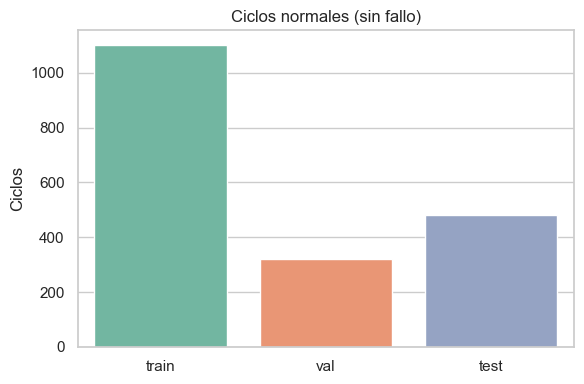

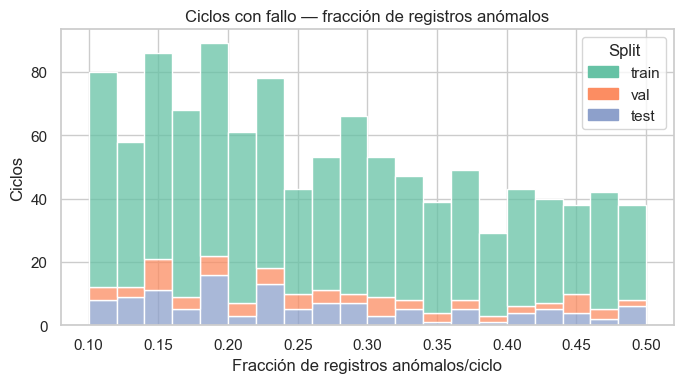

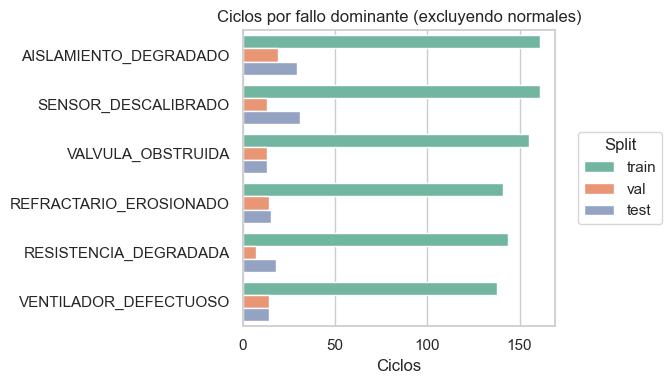

In [5]:
def mode_or_normal(values: pd.Series) -> str:
    values = values[values != "NORMAL"]
    if values.empty:
        return "NORMAL"
    return str(values.value_counts().idxmax())


cycle_rows = []
if id_column and id_column in df.columns:
    for (split_name, cycle_id), group in df.groupby(["split", id_column], sort=False):
        anomaly_mask = group["point_is_anomaly"].to_numpy(dtype=bool)
        cycle_rows.append(
            {
                "split": split_name,
                id_column: cycle_id,
                "n_points": len(group),
                "timestamp_start": group[timestamp_column].iloc[0],
                "timestamp_end": group[timestamp_column].iloc[-1],
                "fault_points": int(anomaly_mask.sum()),
                "fault_fraction": float(anomaly_mask.mean()),
                "dominant_fault": mode_or_normal(group["fault_base"]),
            }
        )

cycle_summary = pd.DataFrame(cycle_rows)
if cycle_summary.empty:
    print("No hay columna de ciclo/ID; se omite el resumen por ciclo.")
else:
    display(cycle_summary.head())
    display(
        cycle_summary.groupby(["split", "dominant_fault"])
        .size()
        .unstack(level="split")
        .rename(columns={"train": "ciclos_train", "val": "ciclos_val", "test": "ciclos_test"})
        .rename_axis("dominant_fault")
        .loc[:, ["ciclos_train", "ciclos_val", "ciclos_test"]]
    )

    normal_cycles = cycle_summary[cycle_summary["fault_fraction"] == 0]
    fault_cycles = cycle_summary[cycle_summary["fault_fraction"] > 0]

    plt.figure(figsize=(6, 4))
    sns.countplot(data=normal_cycles, x="split", palette="Set2")
    plt.title("Ciclos normales (sin fallo)")
    plt.xlabel("")
    plt.ylabel("Ciclos")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.histplot(data=fault_cycles, x="fault_fraction", hue="split", bins=20, multiple="stack", palette="Set2", legend=False)
    plt.title("Ciclos con fallo — fracción de registros anómalos")
    plt.xlabel("Fracción de registros anómalos/ciclo")
    plt.ylabel("Ciclos")
    from matplotlib.patches import Patch
    palette_colors = sns.color_palette("Set2")
    custom_legend = [Patch(color=palette_colors[i], label=s) for i, s in enumerate(["train", "val", "test"])]
    plt.legend(handles=custom_legend, title="Split", loc="upper right")
    plt.tight_layout()
    plt.show()

    fault_only = cycle_summary[cycle_summary["dominant_fault"] != "NORMAL"]
    plt.figure(figsize=(7, 4))
    sns.countplot(data=fault_only, y="dominant_fault", hue="split", palette="Set2", order=fault_only["dominant_fault"].value_counts().index)
    plt.title("Ciclos por fallo dominante (excluyendo normales)")
    plt.xlabel("Ciclos")
    plt.ylabel("")
    plt.legend(title="Split", bbox_to_anchor=(1.05, 0.5), loc="center left")
    plt.tight_layout()
    plt.show()

## 4) Construcción de ventanas y metadatos

Este apartado crea las ventanas temporales usando `create_sequences()` con los mismos parámetros que el pipeline. A partir de las etiquetas devueltas por `create_sequences`, se construye una tabla de metadatos por ventana: split, ciclo, posición inicial y final, timestamps, número de registros anómalos, fracción de fallo, fallo dominante y la etiqueta binaria (`window_label`) proveniente directamente de `y_labels`.

No hay reclasificación ni duplicación: `window_label` es exactamente lo que devuelve `create_sequences()`. La columna `fault_fraction` es un valor continuo (0–1) calculado con `_anomaly_mask` solo para inspección: permite ver qué fracción de cada ventana está afectada por fallo, independientemente de si cruzó o no el umbral del 50 % que determina la etiqueta.

In [6]:
def build_window_metadata(frame: pd.DataFrame, split_name: str, y_labels: np.ndarray, timestamp_windows: list[tuple]) -> pd.DataFrame:
    """Construye una tabla de metadatos para cada ventana generada por create_sequences.

    Usa y_labels directamente como window_label para evitar reclasificar.
    Llama a _anomaly_mask solo para extraer fault_fraction continuo, fault_regist y dominant_fault.
    """
    sort_cols = [timestamp_column]
    entity_col = id_column if id_column and id_column in frame.columns else None
    if entity_col:
        sort_cols = [entity_col, timestamp_column]
    work = frame[sort_cols + [target_column]].sort_values(sort_cols).reset_index(drop=True)

    records = []
    cursor = 0

    if entity_col:
        groups = work.groupby(entity_col, sort=False)
    else:
        groups = [(None, work)]

    for entity_value, group in groups:
        if len(group) < seq_length:
            continue
        labels = group[target_column].to_numpy()
        for start in range(0, len(group) - seq_length + 1, window_step):
            end = start + seq_length
            window_labels = labels[start:end]
            # Etiqueta binaria proviene directamente de y_labels, sin reclasificar
            window_label = int(y_labels[cursor])
            # _anomaly_mask solo para detalles continuos: fault_fraction, fault_regist, dominant_fault
            is_anomaly = _anomaly_mask(window_labels, normal_tokens=normal_tokens)
            fault_fraction = float(is_anomaly.mean())
            fault_regist = int(is_anomaly.sum())
            fault_bases = pd.Series(window_labels[is_anomaly]).map(normalize_fault_name)
            fault_bases = fault_bases[fault_bases != "NORMAL"]
            dominant_fault = "NORMAL" if fault_bases.empty else str(fault_bases.value_counts().idxmax())
            ts_start, ts_end = timestamp_windows[cursor]
            records.append({
                "split": split_name,
                id_column if entity_col else "series_id": entity_value if entity_col else split_name,
                "timestamp_start": ts_start,
                "timestamp_end": ts_end,
                "normal_regist": seq_length - fault_regist,
                "fault_regist": fault_regist,
                "fault_fraction": fault_fraction,
                "dominant_fault": dominant_fault,
                "window_label": window_label,
            })
            cursor += 1
    return pd.DataFrame(records)


X_parts = []
y_parts = []
window_meta_parts = []

for split_name, frame in frames.items():
    cols = [timestamp_column]
    if id_column and id_column in frame.columns:
        cols.append(id_column)
    cols.extend(sensor_cols)
    cols.append(target_column)
    clean = frame[cols]

    X_split, y_split, ts_windows = create_sequences(
        clean,
        target_column=target_column,
        seq_length=seq_length,
        solapamiento_beta=solapamiento_beta,
        id_column=id_column if id_column and id_column in clean.columns else None,
        timestamp_column=timestamp_column,
        normal_tokens=normal_tokens,
    )
    meta_split = build_window_metadata(frame, split_name, y_split, ts_windows)
    X_parts.append(X_split)
    y_parts.append(y_split)
    window_meta_parts.append(meta_split)
    print(f"{split_name}: ventanas={len(meta_split):,}")

X_all = np.concatenate(X_parts, axis=0)
y_all = np.concatenate(y_parts, axis=0)
windows_df = pd.concat(window_meta_parts, ignore_index=True)

print(f"Ventanas totales: {len(windows_df):,}")
display(windows_df.head(15))

train: ventanas=10,000
val: ventanas=2,000
test: ventanas=3,000
Ventanas totales: 15,000


,split,cycle_id,timestamp_start,timestamp_end,normal_regist,fault_regist,fault_fraction,dominant_fault,window_label
0,train,0,2026-01-01 00:00:00,2026-01-01 02:59:00,180,0,0.000000,NORMAL,0
1,train,0,2026-01-01 01:30:00,2026-01-01 04:29:00,180,0,0.000000,NORMAL,0
2,train,0,2026-01-01 03:00:00,2026-01-01 05:59:00,180,0,0.000000,NORMAL,0
3,train,0,2026-01-01 04:30:00,2026-01-01 07:29:00,180,0,0.000000,NORMAL,0
4,train,0,2026-01-01 06:00:00,2026-01-01 08:59:00,180,0,0.000000,NORMAL,0
5,train,1,2026-01-01 12:00:00,2026-01-01 14:59:00,180,0,0.000000,NORMAL,0
6,train,1,2026-01-01 13:30:00,2026-01-01 16:29:00,180,0,0.000000,NORMAL,0
7,train,1,2026-01-01 15:00:00,2026-01-01 17:59:00,180,0,0.000000,NORMAL,0
8,train,1,2026-01-01 16:30:00,2026-01-01 19:29:00,167,13,0.072222,SENSOR_DESCALIBRADO,0
9,train,1,2026-01-01 18:00:00,2026-01-01 20:59:00,77,103,0.572222,SENSOR_DESCALIBRADO,1


## 5) Balance de ventanas y efecto del umbral del 50 %

Este apartado analiza la distribución de la etiqueta final a nivel de ventana, que es la unidad realmente usada por el modelo. Las dos tablas muestran el número de ventanas y el porcentaje de ventanas normales/anómalas por split y en total.

La primera gráfica representa el conteo de ventanas por etiqueta y split. Es la lectura principal del balance supervisado: si las ventanas anómalas son muy escasas, el modelo puede tender a predecir normalidad.

La segunda gráfica muestra, solo para ventanas con algún registro anómalo, qué proporción de la ventana está afectada. La línea vertical marca el umbral del 50 %. A la izquierda hay ventanas con señales de fallo pero etiqueta normal; a la derecha hay ventanas etiquetadas como anomalía. Esta gráfica muestra que no todo contacto con un fallo convierte automáticamente la ventana en positiva: se necesita al menos el 50% de fallo.

Ventanas:


split,train,val,test,Total
Anomalía,1351,121,171,1643
Normal,8649,1879,2829,13357



%:


split,train,val,test,Total
Anomalía,13.51,6.05,5.7,8.42
Normal,86.49,93.95,94.3,91.58


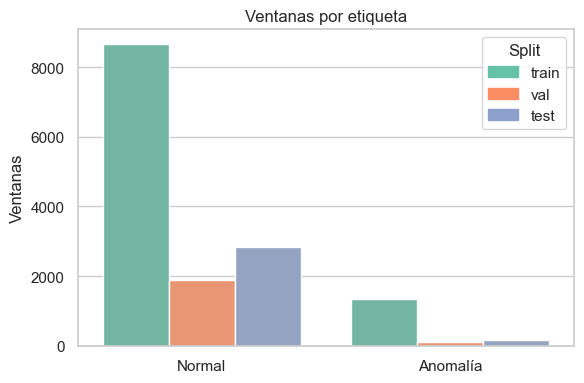

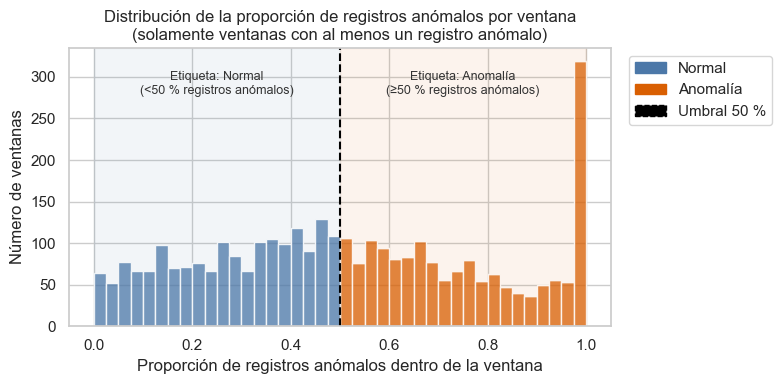

In [7]:
window_state_map = {0: "Normal", 1: "Anomalía"}
windows_df["window_state"] = windows_df["window_label"].map(window_state_map)

pivot = (
    windows_df.groupby(["split", "window_state"])
    .size()
    .unstack(level="split")
    .rename_axis(None)
)
pivot["Total"] = pivot.sum(axis=1)
pivot = pivot[["train", "val", "test", "Total"]]

porcentaje = (
    windows_df.groupby(["split", "window_state"])
    .size()
    .unstack(level="split")
    .apply(lambda x: x / x.sum() * 100, axis=0)
    .round(2)
    .rename_axis(None)
)
porcentaje["Total"] = (porcentaje.sum(axis=1) / porcentaje.sum(axis=1).sum() * 100).round(2)
porcentaje = porcentaje[["train", "val", "test", "Total"]]

print("Ventanas:")
display(pivot)
print("\n%:")
display(porcentaje)

from matplotlib.patches import Patch

plt.figure(figsize=(6, 4))
sns.countplot(data=windows_df, x="window_state", hue="split", palette="Set2", legend=False)
plt.title("Ventanas por etiqueta")
plt.xlabel("")
plt.ylabel("Ventanas")
palette_colors = sns.color_palette("Set2")
custom_legend = [Patch(color=palette_colors[i], label=s) for i, s in enumerate(["train", "val", "test"])]
plt.legend(handles=custom_legend, title="Split", loc="upper right")
plt.tight_layout()
plt.show()

windows_con_fallo = windows_df[windows_df["fault_fraction"] > 0]

plt.figure(figsize=(8, 4))
bins = np.linspace(0, 1, 41)
ax = sns.histplot(data=windows_con_fallo, x="fault_fraction", hue="window_state", bins=bins, multiple="stack", palette=["#4C78A8", "#D95F02"], legend=False)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5)
ax.axvspan(0, 0.5, alpha=0.07, color="#4C78A8")
ax.axvspan(0.5, 1, alpha=0.07, color="#D95F02")
ax.text(0.25, ax.get_ylim()[1] * 0.92, "Etiqueta: Normal\n(<50 % registros anómalos)", ha="center", va="top", fontsize=9, color="#333")
ax.text(0.75, ax.get_ylim()[1] * 0.92, "Etiqueta: Anomalía\n(≥50 % registros anómalos)", ha="center", va="top", fontsize=9, color="#333")
plt.title("Distribución de la proporción de registros anómalos por ventana\n(solamente ventanas con al menos un registro anómalo)")
plt.xlabel("Proporción de registros anómalos dentro de la ventana")
plt.ylabel("Número de ventanas")
custom_legend3 = [Patch(color="#4C78A8", label="Normal"), Patch(color="#D95F02", label="Anomalía"), Patch(color="black", linestyle="--", label="Umbral 50 %")]
plt.legend(handles=custom_legend3, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 6) Fallo dominante en ventanas anómalas

Este apartado se centra en las ventanas etiquetadas como anomalía. La tabla cuenta cuántas ventanas positivas hay por `dominant_fault` y split. Esta variable no es el target binario del modelo, pero ayuda a interpretar qué tipo de fallo explica mayoritariamente cada ventana anómala.

La gráfica de barras horizontales muestra la misma distribución de forma visual. Si un fallo tiene muy pocas ventanas positivas, su interpretación y evaluación serán menos robustas. Si el reparto por split es parecido, el modelo verá ejemplos comparables durante entrenamiento y evaluación.


--- TRAIN (total: 1351 ventanas) ---


,dominant_fault,ventanas,% del total
3,SENSOR_DESCALIBRADO,265,19.6%
1,REFRACTARIO_EROSIONADO,232,17.2%
4,VALVULA_OBSTRUIDA,226,16.7%
0,AISLAMIENTO_DEGRADADO,220,16.3%
2,RESISTENCIA_DEGRADADA,220,16.3%
5,VENTILADOR_DEFECTUOSO,188,13.9%



--- VAL (total: 121 ventanas) ---


,dominant_fault,ventanas,% del total
5,VENTILADOR_DEFECTUOSO,25,20.7%
3,SENSOR_DESCALIBRADO,24,19.8%
0,AISLAMIENTO_DEGRADADO,22,18.2%
1,REFRACTARIO_EROSIONADO,18,14.9%
4,VALVULA_OBSTRUIDA,17,14.0%
2,RESISTENCIA_DEGRADADA,15,12.4%



--- TEST (total: 171 ventanas) ---


,dominant_fault,ventanas,% del total
3,SENSOR_DESCALIBRADO,47,27.5%
0,AISLAMIENTO_DEGRADADO,39,22.8%
2,RESISTENCIA_DEGRADADA,25,14.6%
1,REFRACTARIO_EROSIONADO,23,13.5%
4,VALVULA_OBSTRUIDA,20,11.7%
5,VENTILADOR_DEFECTUOSO,17,9.9%


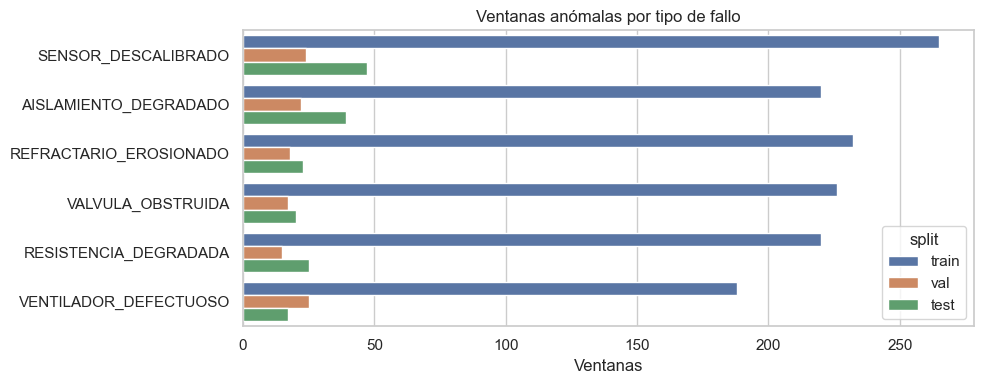

In [8]:
positive_windows = windows_df[windows_df["window_label"].eq(1)].copy()

if positive_windows.empty:
    print("No hay ventanas positivas con el criterio actual.")
else:
    for split_name in ["train", "val", "test"]:
        split_data = positive_windows[positive_windows["split"] == split_name]
        if split_data.empty:
            continue

        total = len(split_data)
        counts = (
            split_data.groupby("dominant_fault")
            .size()
            .rename("ventanas")
            .reset_index()
            .sort_values("ventanas", ascending=False)
        )
        counts["% del total"] = (counts["ventanas"] / total * 100).round(1)

        print(f"\n--- {split_name.upper()} (total: {total} ventanas) ---")
        display(counts.style.format({"% del total": "{:.1f}%"}))

    plt.figure(figsize=(10, 4))
    sns.countplot(data=positive_windows, y="dominant_fault", hue="split", order=positive_windows["dominant_fault"].value_counts().index)
    plt.title("Ventanas anómalas por tipo de fallo")
    plt.xlabel("Ventanas")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

## 7) Perfil temporal medio de sensores por estado

Este apartado normaliza la posición dentro del ciclo como `cycle_progress` y calcula la evolución media de sensores seleccionados para registros normales y anómalos. Cada subgráfica corresponde a un sensor y compara ambas curvas a lo largo del ciclo.

La interpretación se basa en la separación entre curvas. Si una variable muestra una diferencia clara en los tramos anómalos, probablemente captura una señal física asociada al fallo. Si las curvas se solapan casi por completo, esa variable aporta menos información temporal para distinguir estados en ese perfil agregado.

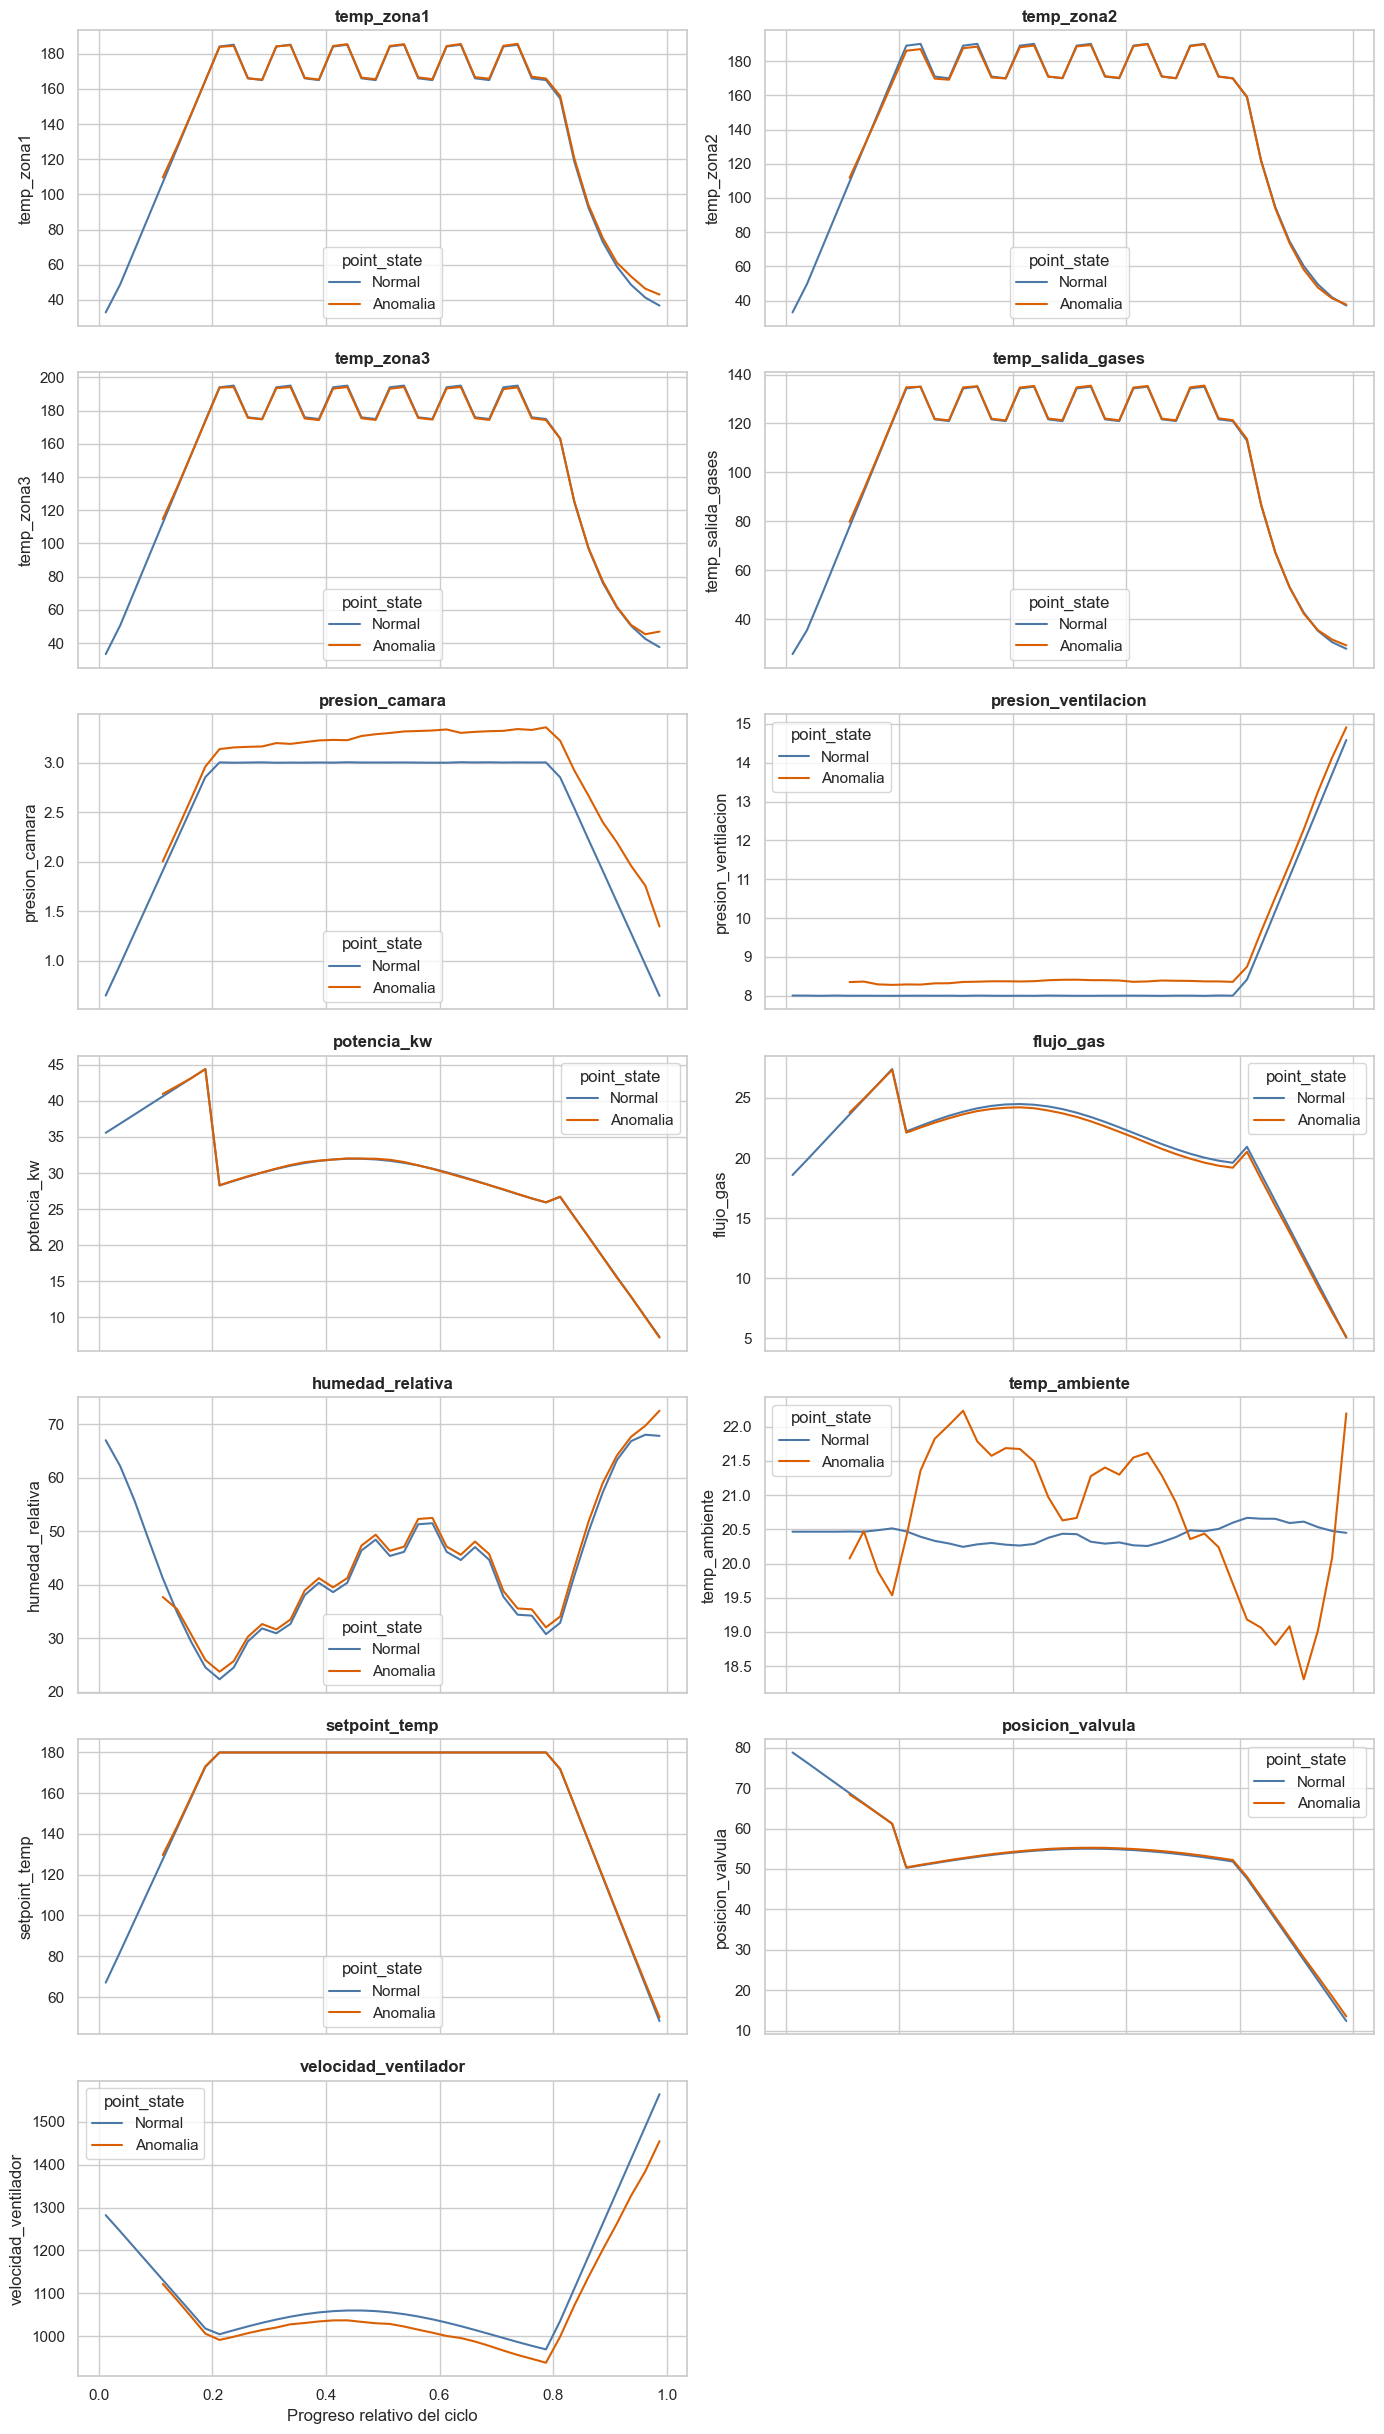

In [9]:
profile_df = df.copy()
if id_column and id_column in profile_df.columns:
    profile_df["sample_in_cycle"] = profile_df.groupby(["split", id_column]).cumcount()
    profile_df["cycle_length"] = profile_df.groupby(["split", id_column])[id_column].transform("size")
    denominator = (profile_df["cycle_length"] - 1).replace(0, np.nan)
    profile_df["cycle_progress"] = (profile_df["sample_in_cycle"] / denominator).fillna(0.0)
else:
    profile_df["cycle_progress"] = np.linspace(0, 1, len(profile_df))

selected_sensors = sensor_cols
profile_df["progress_bin"] = pd.cut(profile_df["cycle_progress"], bins=np.linspace(0, 1, 41), include_lowest=True)
profile = (
    profile_df.groupby(["progress_bin", "point_state"], observed=True)[selected_sensors]
    .mean()
    .reset_index()
)
profile["cycle_progress"] = profile["progress_bin"].apply(lambda interval: interval.mid).astype(float)

n_cols = 2
n_rows = int(np.ceil(len(selected_sensors) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=True, sharey=False)
axes = np.asarray(axes).reshape(-1)
for ax, sensor in zip(axes, selected_sensors):
    sns.lineplot(data=profile, x="cycle_progress", y=sensor, hue="point_state", ax=ax, palette=["#4C78A8", "#D95F02"])
    ax.set_title(sensor, fontweight="bold")
    ax.set_xlabel("Progreso relativo del ciclo")
    ax.set_ylabel(sensor)
for ax in axes[len(selected_sensors):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 8) Estadísticos por ventana y ranking de separabilidad

Este apartado convierte cada ventana en un conjunto de estadísticos mediante `stats_windows()`; por ejemplo, medias, desviaciones, pendientes, máximos y mínimos por sensor. La primera tabla une metadatos de ventana con algunas de estas características para comprobar que el espacio tabular queda alineado con la etiqueta de ventana.

La segunda tabla ordena las características por `abs_cohen_d`, una medida de separación estandarizada entre ventanas normales y anómalas. El signo de `cohen_d` indica dirección: positivo significa valores mayores en anomalía; negativo, valores mayores en normalidad. Como regla práctica, valores absolutos superiores a 0.8 indican separación alta, alrededor de 0.5 separación media y por debajo de 0.2 separación débil.

La gráfica de barras resume las características más discriminantes. Barras largas indican variables estadísticas con mayor diferencia entre clases; la dirección de la barra ayuda a saber si la anomalía aumenta o reduce esa magnitud.

Stats por ventana: (15000, 65)


,split,window_state,fault_fraction,dominant_fault,mean_temp_zona1,mean_temp_zona2,mean_temp_zona3,mean_temp_salida_gases,mean_presion_camara,mean_presion_ventilacion,mean_potencia_kw,mean_flujo_gas
0,train,Normal,0.0,NORMAL,128.444185,131.673612,135.094674,93.512356,2.144918,7.973774,36.417721,22.973709
1,train,Normal,0.0,NORMAL,173.641415,178.587077,183.321780,126.925114,2.946441,7.975697,32.778250,24.248628
2,train,Normal,0.0,NORMAL,175.009629,180.165809,184.872686,128.059439,2.995212,7.935157,31.447236,23.929831
3,train,Normal,0.0,NORMAL,175.132272,180.134862,184.908657,128.095914,3.027959,7.994935,30.018259,22.279614
4,train,Normal,0.0,NORMAL,155.564932,159.856923,163.982494,113.681487,2.811631,8.613734,26.140689,19.628140


,feature,cohen_d,abs_cohen_d,mean_normal,mean_anomaly
43,max_presion_camara,1.257061,1.257061,3.849047,4.539144
5,mean_presion_ventilacion,0.995673,0.995673,8.125319,8.429460
39,max_temp_zona1,0.980367,0.980367,192.064545,194.801108
4,mean_presion_camara,0.936972,0.936972,2.776450,3.114773
12,mean_velocidad_ventilador,-0.896485,0.896485,1055.402098,1025.237824
22,std_temp_ambiente,0.880818,0.880818,0.011718,0.088448
42,max_temp_salida_gases,0.742350,0.742350,141.354239,142.363945
64,min_velocidad_ventilador,-0.669728,0.669728,988.042450,952.013856
40,max_temp_zona2,0.616827,0.616827,197.106528,199.603198
41,max_temp_zona3,0.601456,0.601456,202.001426,203.621820


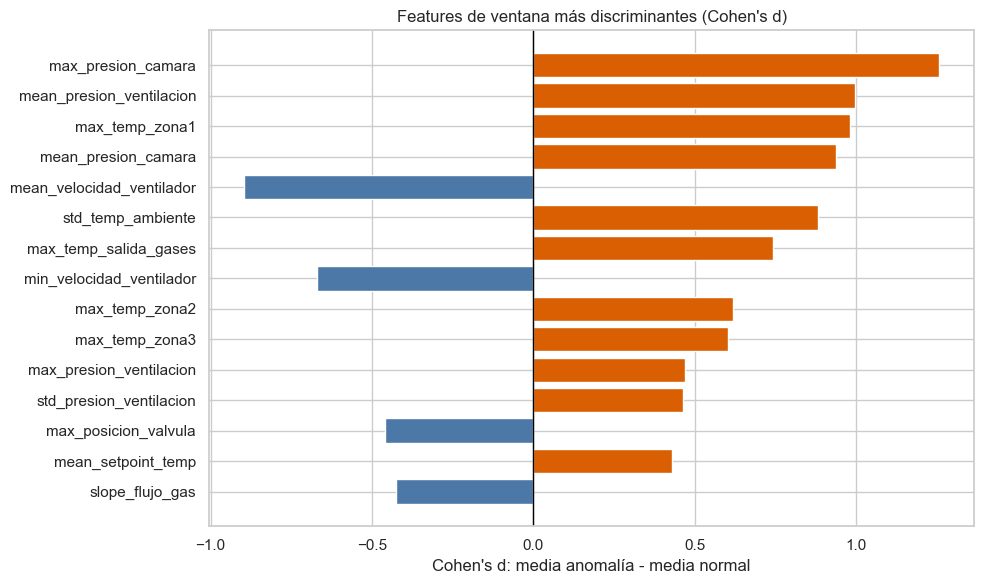

In [10]:
stats_df = stats_windows(
    X_all,
    feature_names=sensor_cols,
    stats_creation=stats_creation,
    ddof=0,
)
stat_cols = stats_df.columns.tolist()
stats_labeled = pd.concat([windows_df.reset_index(drop=True), stats_df.reset_index(drop=True)], axis=1)

print(f"Stats por ventana: {stats_df.shape}")
display(stats_labeled[["split", "window_state", "fault_fraction", "dominant_fault", *stat_cols[:8]]].head())


def cohen_d(normal_values: pd.Series, anomaly_values: pd.Series) -> float:
    normal_values = pd.to_numeric(normal_values, errors="coerce").dropna()
    anomaly_values = pd.to_numeric(anomaly_values, errors="coerce").dropna()
    if len(normal_values) < 2 or len(anomaly_values) < 2:
        return np.nan
    n0, n1 = len(normal_values), len(anomaly_values)
    pooled = np.sqrt(((n0 - 1) * normal_values.var(ddof=1) + (n1 - 1) * anomaly_values.var(ddof=1)) / (n0 + n1 - 2))
    if pooled == 0 or np.isnan(pooled):
        return np.nan
    return float((anomaly_values.mean() - normal_values.mean()) / pooled)


effect_rows = []
normal_mask = stats_labeled["window_label"].eq(0)
anomaly_mask = stats_labeled["window_label"].eq(1)
for col in stat_cols:
    d = cohen_d(stats_labeled.loc[normal_mask, col], stats_labeled.loc[anomaly_mask, col])
    effect_rows.append(
        {
            "feature": col,
            "cohen_d": d,
            "abs_cohen_d": abs(d) if pd.notna(d) else np.nan,
            "mean_normal": stats_labeled.loc[normal_mask, col].mean(),
            "mean_anomaly": stats_labeled.loc[anomaly_mask, col].mean(),
        }
    )

effect_df = pd.DataFrame(effect_rows).sort_values("abs_cohen_d", ascending=False)
display(effect_df.head(20))

plot_effect = effect_df.dropna(subset=["abs_cohen_d"]).head(15).sort_values("abs_cohen_d")
if plot_effect.empty:
    print("No se puede calcular separabilidad: falta una de las clases o no hay varianza suficiente.")
else:
    plt.figure(figsize=(10, 6))
    plt.barh(plot_effect["feature"], plot_effect["cohen_d"], color=np.where(plot_effect["cohen_d"] >= 0, "#D95F02", "#4C78A8"))
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Features de ventana más discriminantes (Cohen's d)")
    plt.xlabel("Cohen's d: media anomalía - media normal")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

## 9) Distribución de las características más discriminantes

Este apartado toma las características mejor posicionadas en el ranking anterior y muestra sus distribuciones para ventanas normales y anómalas mediante curvas KDE. Cada subgráfica corresponde a una característica estadística concreta.

Si las curvas azul y naranja están bien separadas, esa característica ayuda a distinguir clases. Si se solapan mucho, su utilidad individual es menor aunque pueda aportar información combinada con otras variables. Esta vista complementa Cohen's d porque permite detectar asimetrías, colas o rangos donde las clases se mezclan.

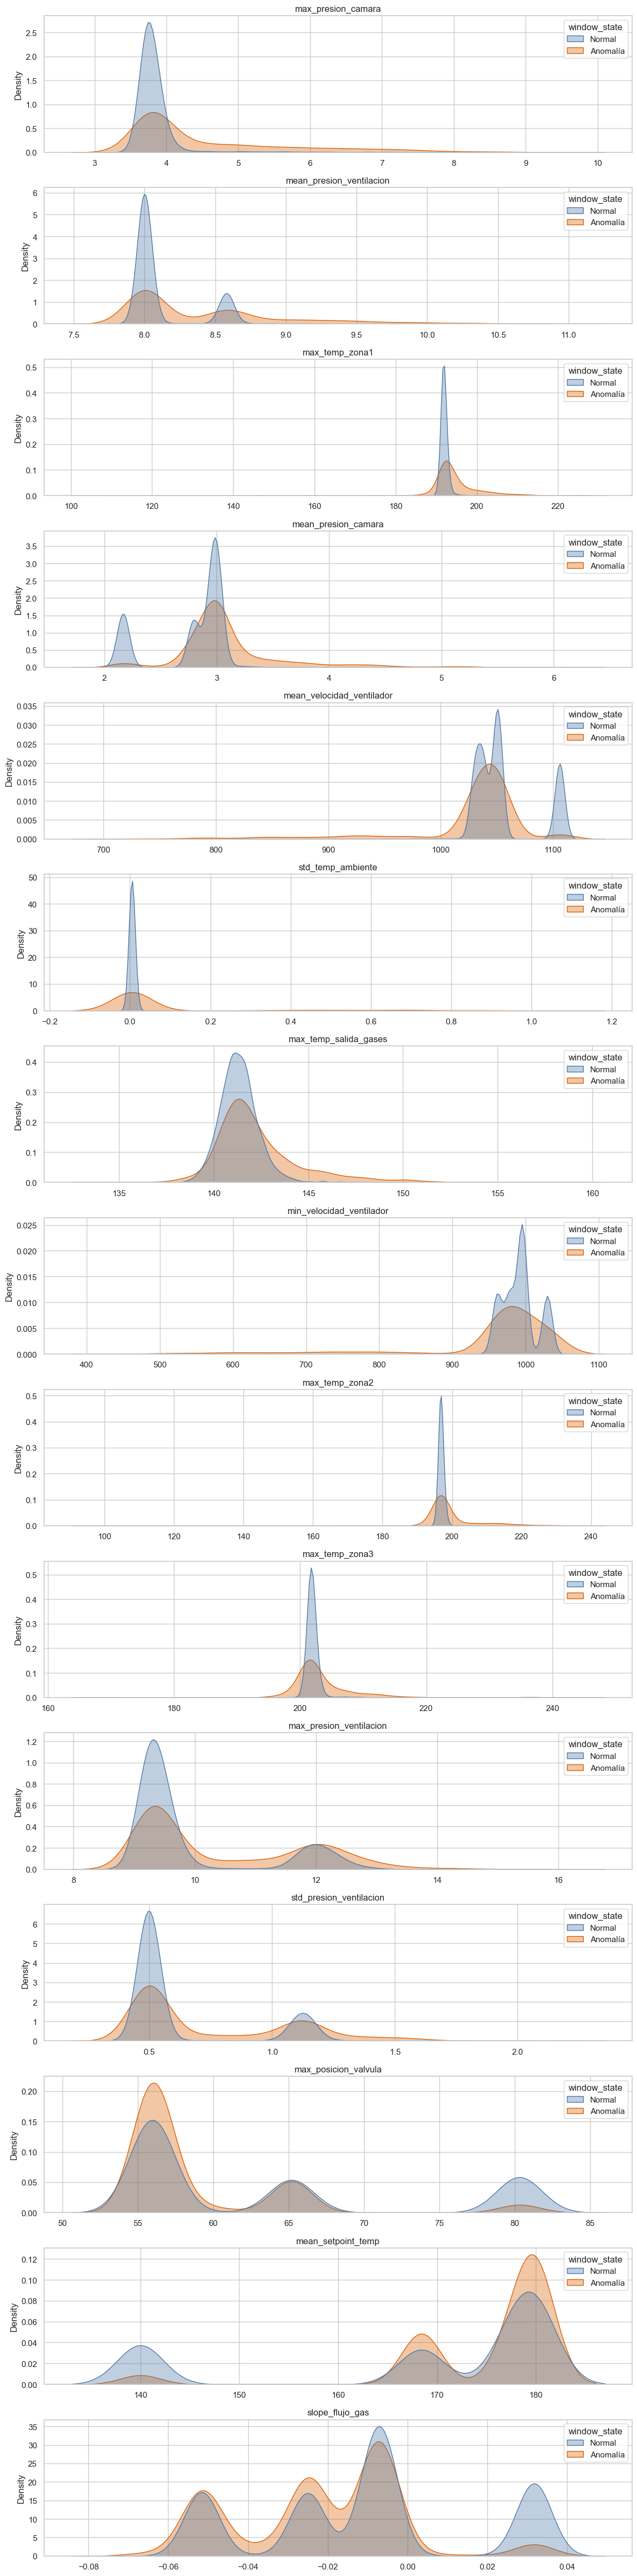

In [11]:
top_features = effect_df.dropna(subset=["abs_cohen_d"]).head(15)["feature"].tolist()
if not top_features:
    print("No hay features con efecto calculable para representar.")
else:
    fig, axes = plt.subplots(len(top_features), 1, figsize=(12, 3.2 * len(top_features)))
    axes = np.atleast_1d(axes)
    for ax, feature in zip(axes, top_features):
        sns.kdeplot(data=stats_labeled, x=feature, hue="window_state", common_norm=False, fill=True, alpha=0.35, ax=ax, palette=["#4C78A8", "#D95F02"])
        ax.set_title(feature)
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()


## 10) PCA de estadísticas de ventana

El PCA proyecta el conjunto de estadísticos de ventana a dos componentes principales para visualizar estructura global. Antes de aplicar PCA, las características se imputan y escalan para que variables con distinta unidad no dominen la proyección.

La primera gráfica colorea las ventanas por etiqueta normal/anomalía. Si ambos colores ocupan regiones distintas, hay separación global en el espacio estadístico; si se mezclan, la discriminación requiere fronteras más complejas o señales más sutiles.

La varianza explicada de PC1 y PC2 indica qué parte de la información original queda representada en esta vista bidimensional, por lo que el PCA debe interpretarse como apoyo visual y no como prueba definitiva. 

En el gráfico por fallo dominante, grupos de color compactos indican modos de fallo con patrones estadísticos diferenciados. Si los puntos aparecen muy mezclados, no significa necesariamente que el modelo no pueda aprender, pero sí que la separación no es evidente en solo dos dimensiones.

Varianza explicada por componente:
  PC1: 42.25%
  PC2: 25.68%
  Total (PC1+PC2): 67.93%


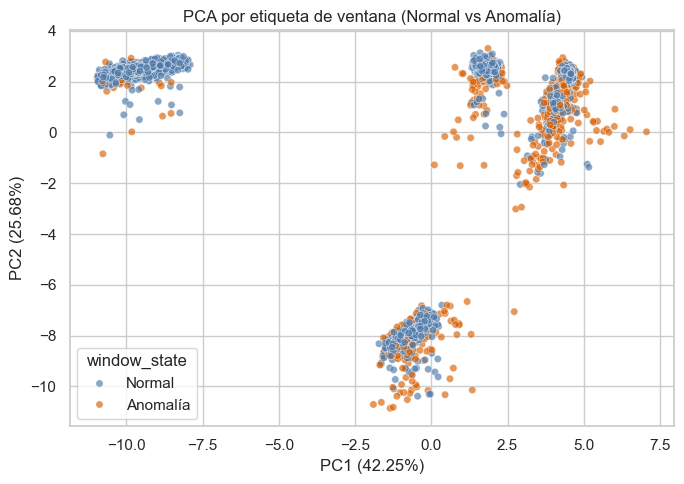

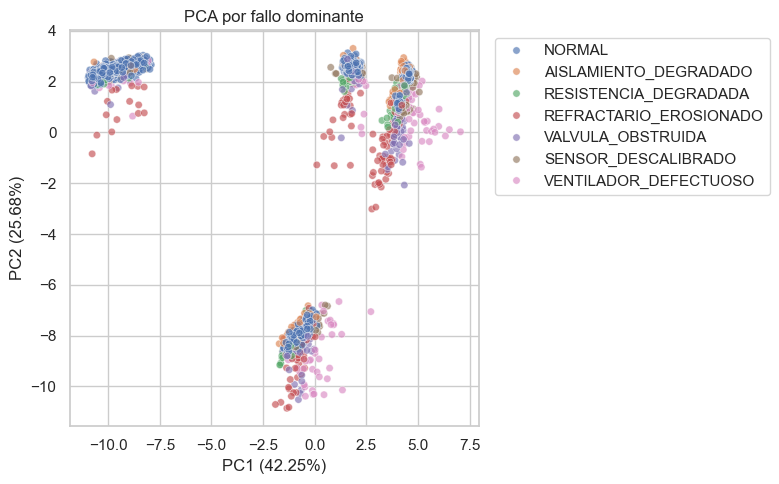

In [12]:
X_stats = stats_labeled[stat_cols]
X_stats_prepared = SimpleImputer(strategy="median").fit_transform(X_stats)
X_stats_scaled = StandardScaler().fit_transform(X_stats_prepared)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_stats_scaled)
pca_df = windows_df[["split", "window_state", "dominant_fault", "fault_fraction"]].copy()
pca_df["PC1"] = coords[:, 0]
pca_df["PC2"] = coords[:, 1]

evr = pca.explained_variance_ratio_
print("Varianza explicada por componente:")
print(f"  PC1: {evr[0]:.2%}")
print(f"  PC2: {evr[1]:.2%}")
print(f"  Total (PC1+PC2): {evr.sum():.2%}")

plot_pca = pca_df.sample(n=min(len(pca_df), 5000), random_state=42)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_pca, x="PC1", y="PC2", hue="window_state", alpha=0.65, s=28, palette=["#4C78A8", "#D95F02"])
plt.title("PCA por etiqueta de ventana (Normal vs Anomalía)")
plt.xlabel(f"PC1 ({evr[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({evr[1]*100:.2f}%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_pca, x="PC1", y="PC2", hue="dominant_fault", alpha=0.65, s=28)
plt.title("PCA por fallo dominante")
plt.xlabel(f"PC1 ({evr[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({evr[1]*100:.2f}%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11) Correlación entre características estadísticas seleccionadas

Este apartado calcula la correlación entre las características con mayor separabilidad. La matriz de calor muestra relaciones lineales entre pares de variables: valores cercanos a 1 o -1 indican que dos características se mueven de forma muy parecida o inversa; valores cercanos a 0 indican poca relación lineal.

La tabla final lista los pares con mayor correlación absoluta. Sirve para detectar redundancia: si varias características aportan casi la misma información, conviene tenerlo en cuenta al interpretar importancia de variables o al simplificar el espacio de entrada. En este EDA no se eliminan variables; solo se señala la posible redundancia.

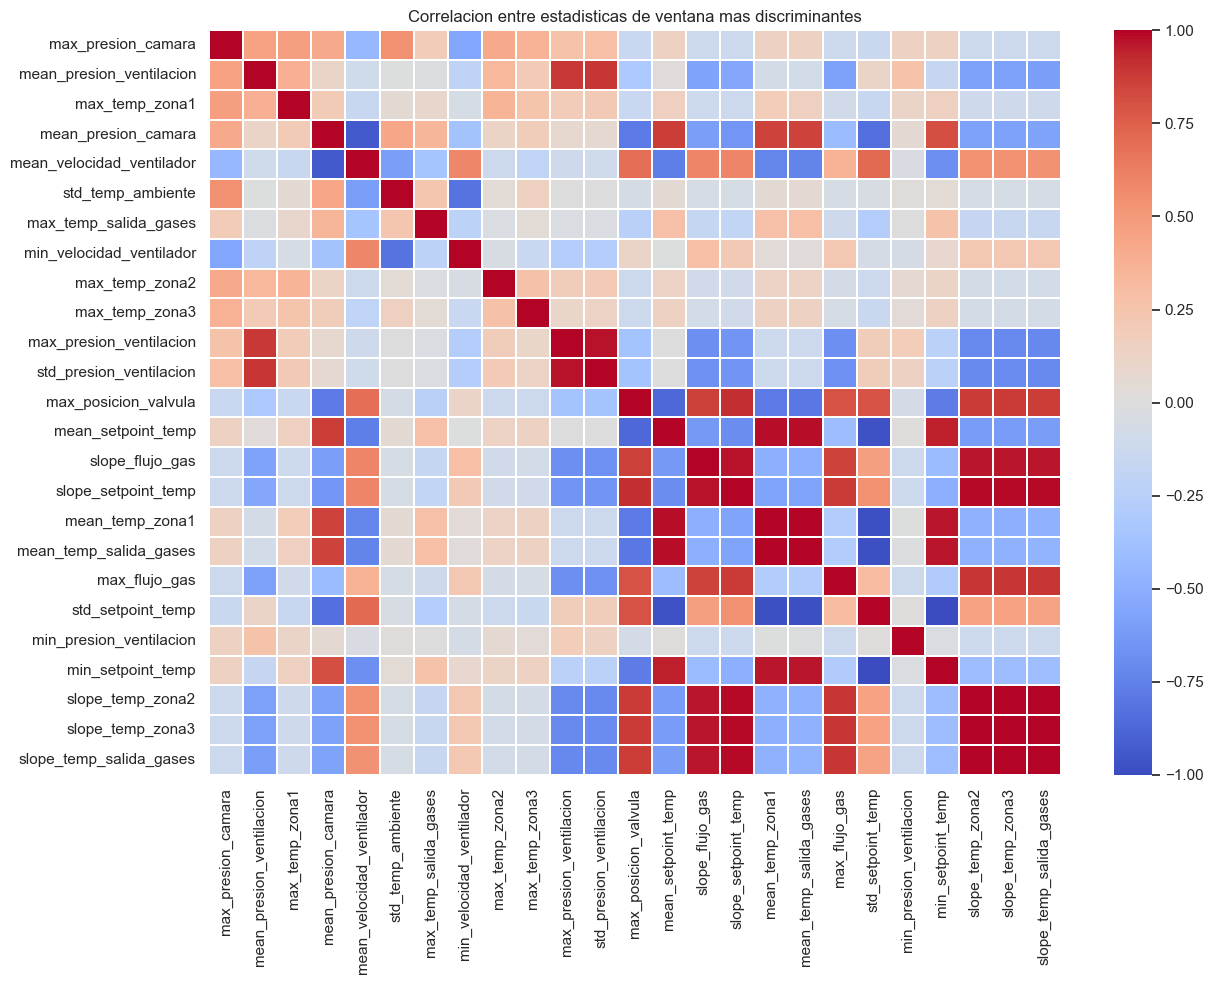

abs_corr
slope_temp_zona2          slope_temp_zona3           0.998378
mean_temp_zona1           mean_temp_salida_gases     0.998349
slope_temp_zona3          slope_temp_salida_gases    0.998258
slope_temp_zona2          slope_temp_salida_gases    0.998000
std_setpoint_temp         min_setpoint_temp          0.994825
slope_setpoint_temp       slope_temp_zona3           0.991326
                          slope_temp_zona2           0.990822
                          slope_temp_salida_gases    0.990436
mean_temp_salida_gases    std_setpoint_temp          0.983259
mean_setpoint_temp        mean_temp_salida_gases     0.981474
mean_temp_zona1           std_setpoint_temp          0.980024
mean_setpoint_temp        mean_temp_zona1            0.979048
max_presion_ventilacion   std_presion_ventilacion    0.976536
mean_setpoint_temp        std_setpoint_temp          0.975334
slope_flujo_gas           slope_setpoint_temp        0.971049
                          slope_temp_zona3           0.966480
                          slope_temp_zona2           0.965920
                          slope_temp_salida_gases    0.965794
mean_temp_salida_gases    min_setpoint_temp          0.965069
mean_temp_zona1           min_setpoint_temp          0.961579
mean_setpoint_temp        min_setpoint_temp          0.950107
mean_presion_camara       mean_velocidad_ventilador  0.931439
max_posicion_valvula      slope_setpoint_temp        0.918187
max_flujo_gas             slope_temp_salida_gases    0.895087
mean_presion_ventilacion  std_presion_ventilacion    0.893261
max_flujo_gas             slope_temp_zona2           0.890945
                          slope_temp_zona3           0.890853
mean_presion_ventilacion  max_presion_ventilacion    0.886262
max_posicion_valvula      slope_temp_zona3           0.879063
                          slope_temp_zona2           0.877848
slope_setpoint_temp       max_flujo_gas              0.875669
max_posicion_valvula      slope_temp_salida_gases    0.874089
mean_presion_camara       mean_setpoint_temp         0.872259
max_posicion_valvula      mean_setpoint_temp         0.869510
                          slope_flujo_gas            0.863148
slope_flujo_gas           max_flujo_gas              0.854796
mean_presion_camara       mean_temp_salida_gases     0.854316
                          mean_temp_zona1            0.851612
                          std_setpoint_temp          0.840995
                          min_setpoint_temp          0.817143
std_temp_ambiente         min_velocidad_ventilador   0.813960
max_posicion_valvula      max_flujo_gas              0.800337
                          std_setpoint_temp          0.799443
                          mean_temp_salida_gases     0.789882
                          mean_temp_zona1            0.788436
mean_presion_camara       max_posicion_valvula       0.783248
max_posicion_valvula      min_setpoint_temp          0.777618
mean_velocidad_ventilador mean_setpoint_temp         0.758580
                          mean_temp_salida_gases     0.738857
                          mean_temp_zona1            0.732142

In [13]:
selected_corr_features = effect_df.dropna(subset=["abs_cohen_d"]).head(25)["feature"].tolist()
if len(selected_corr_features) < 2:
    print("No hay suficientes features para calcular una matriz de correlacion informativa.")
else:
    corr = stats_labeled[selected_corr_features].corr()
    plt.figure(figsize=(13, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=False, linewidths=0.2)
    plt.title("Correlacion entre estadisticas de ventana mas discriminantes")
    plt.tight_layout()
    plt.show()

    corr_pairs = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
    display(corr_pairs.head(50).rename("abs_corr").to_frame())